In [2]:
import kagglehub
import tensorflow as tf
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:

path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")

print("Path to dataset files:", path)

Path to dataset files: /Users/kj/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1


In [4]:
# Read folder, to classify between detect and non detect

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

candidates = [
    Path("data/Decks"),
    Path("data/Decks"),
    Path("data/Decks"),
]

data_dir = next((p for p in candidates if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find dataset folder. Tried: " + ", ".join(str(p) for p in candidates)
    )


subdirs = [p for p in data_dir.iterdir() if p.is_dir()]
if len(subdirs) < 2:
    raise ValueError(
        f"{data_dir} does not contain class subfolders. "
        "Create subfolders (e.g. defect/, no_defect/) and put images inside them so labels can be inferred."
    )

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 13622 files belonging to 3 classes.
Using 10898 files for training.
Found 13622 files belonging to 3 classes.
Using 2724 files for validation.
Classes: ['defect', 'no_defect', 'test']


In [5]:
# Break down the image into patches
#TODO: data augmentation, Dedup,  class balancing.
#TODO: add heritage-building, pavements and walls classification function.

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

num_classes = len(class_names)
if num_classes == 2:
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    loss = "binary_crossentropy"
    metrics = ["accuracy", tf.keras.metrics.AUC(name="auc")]
else:
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    loss = "sparse_categorical_crossentropy"
    metrics = ["accuracy"]

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss,
    metrics=metrics,
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
#  Takes long ass time

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.8819 - loss: 0.3503 - val_accuracy: 0.9023 - val_loss: 0.2794
Epoch 2/10
256/341 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9041 - loss: 0.2904

KeyboardInterrupt: 

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=loss,
    metrics=metrics,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
)

Epoch 1/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 91s 260ms/step - accuracy: 0.8924 - loss: 0.3370 - val_accuracy: 0.9126 - val_loss: 0.5520
Epoch 2/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 84s 247ms/step - accuracy: 0.9273 - loss: 0.2085 - val_accuracy: 0.9163 - val_loss: 0.4788
Epoch 3/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 82s 241ms/step - accuracy: 0.9435 - loss: 0.1584 - val_accuracy: 0.9196 - val_loss: 0.3844
Epoch 4/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 88s 257ms/step - accuracy: 0.9584 - loss: 0.1174 - val_accuracy: 0.9203 - val_loss: 0.3144
Epoch 5/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 80s 234ms/step - accuracy: 0.9699 - loss: 0.0861 - val_accuracy: 0.9101 - val_loss: 0.3259


In [ ]:
model.save("defect_model.keras")

Found 13622 files belonging to 3 classes.
Using 2724 files for validation.


2026-03-15 23:23:20.437826: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step
Validation AUC: nan


/Users/kj/Documents/SEM5/ENGG2112/.engg_venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/kj/Documents/SEM5/ENGG2112/.engg_venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


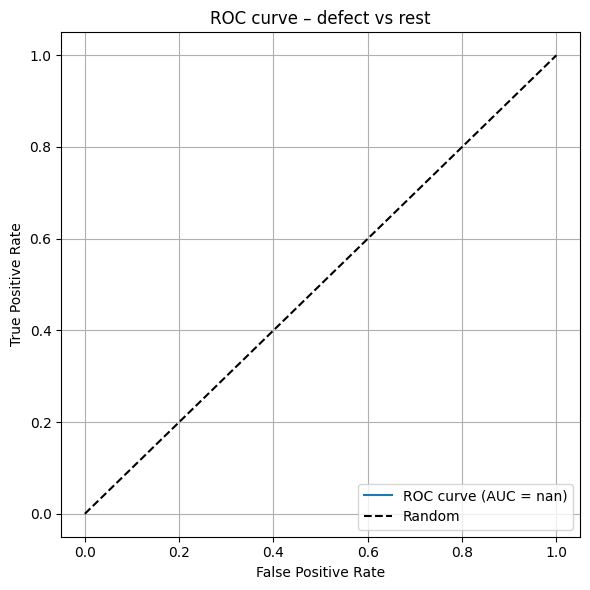

In [ ]:
# recreate validation set without shuffling
val_ds_eval = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

y_true = np.concatenate([y.numpy() for _, y in val_ds_eval])

# get predicted probabilities
y_scores = model.predict(val_ds_eval, verbose=1)

# if binary with sigmoid head: shape (N, 1)
# y_prob = y_scores.ravel()

# if multi-class softmax: pick the 'defect' column
defect_idx = class_names.index("defect")   # adjust if name differs
y_prob = y_scores[:, defect_idx]

# now lengths match
fpr, tpr, thresholds = roc_curve(y_true == defect_idx, y_prob)  # true = 1 for defect
auc_score = roc_auc_score(y_true == defect_idx, y_prob)
print("Validation AUC:", auc_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – defect vs rest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'df_eval' is not defined